In [ ]:
from PIL import Image
import numpy as np
import random
import matplotlib.pyplot as plt
import os
import glob
import random
from typing import List
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from datasets import load_dataset
from skimage.metrics import peak_signal_noise_ratio, structural_similarity


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CROP_SIZE = 33
lr = 1e-5
num_epochs = 100000
batch_size = 8


In [2]:
def random_crop_pair(lr: np.ndarray, hr: np.ndarray, crop_size=33):
    h, w = lr.shape

    if h < crop_size or w < crop_size:
        raise ValueError("Image too small for cropping.")

    x = random.randint(0, w - crop_size)
    y = random.randint(0, h - crop_size)

    lr_crop = lr[y:y+crop_size, x:x+crop_size]
    hr_crop = hr[y:y+crop_size, x:x+crop_size]

    return lr_crop, hr_crop

def make_low_resolution(img: Image.Image, scale: int) -> Image.Image:
    w, h = img.size

    low_w = w // scale
    low_h = h // scale

    img_down = img.resize((low_w, low_h), Image.BILINEAR)

    img_up = img_down.resize((w, h), Image.BILINEAR)

    return img_up

def rgb_to_y(img: Image.Image) -> np.ndarray:
    ycbcr = img.convert("YCbCr")
    y, _, _ = ycbcr.split()
    return np.array(y, dtype=np.float32)

In [3]:
class OnFlyDataset(Dataset):
    def __init__(self, root_dir: str, scale: int = None, seed=None):
        self.root_dir = root_dir
        self.scale = scale
        self.seed = seed

        exts = ("*.png",)
        image_paths: List[str] = []
        for ext in exts:
            image_paths.extend(glob.glob(os.path.join(root_dir, ext)))

        self.image_paths = sorted(image_paths)

        if len(self.image_paths) == 0:
            raise RuntimeError(f"No images found in {root_dir}")


    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        if self.seed is not None:
            random.seed(self.seed + idx)

        scale = self.scale if self.scale is not None else random.choice([2, 3])

        path = self.image_paths[idx]

        hr_img = Image.open(path).convert("RGB")

        lr_img = make_low_resolution(hr_img, scale)

        hr_y = rgb_to_y(hr_img)
        lr_y = rgb_to_y(lr_img)

        lr_crop, hr_crop = random_crop_pair(lr_y, hr_y, crop_size=CROP_SIZE)

        lr_tensor = torch.from_numpy(lr_crop).unsqueeze(0) / 255.0
        hr_tensor = torch.from_numpy(hr_crop).unsqueeze(0) / 255.0

        return lr_tensor, hr_tensor

In [4]:
class SuperResolutionSRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=9, padding=4)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv3 = nn.Conv2d(32, 1, kernel_size=5, padding=2)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.conv3(x)
        return x


model = SuperResolutionSRCNN().to(device)
print(model)

SuperResolutionSRCNN(
  (conv1): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (relu1): ReLU(inplace=True)
  (conv2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU(inplace=True)
  (conv3): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)


In [ ]:
dataset = OnFlyDataset("./T91")
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

epoch_losses = []

counter = 0
for epoch in range(num_epochs):
    model.train()

    lr_batch, hr_batch = next(iter(loader))

    lr_batch = lr_batch.to(device)
    hr_batch = hr_batch.to(device)

    optimizer.zero_grad()
    pred = model(lr_batch)
    loss = criterion(pred, hr_batch)
    loss.backward()
    optimizer.step()

    epoch_losses.append(loss.item())
    if counter % 100 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - loss: {loss.item():.6f}")
    counter += 1

Streaming output truncated to the last 5000 lines.
Epoch 65001/70000 - loss: 0.000691
Epoch 65002/70000 - loss: 0.000982
Epoch 65003/70000 - loss: 0.001936
Epoch 65004/70000 - loss: 0.000842
Epoch 65005/70000 - loss: 0.000522
Epoch 65006/70000 - loss: 0.001261
Epoch 65007/70000 - loss: 0.000398
Epoch 65008/70000 - loss: 0.000805
Epoch 65009/70000 - loss: 0.000787
Epoch 65010/70000 - loss: 0.001575
Epoch 65011/70000 - loss: 0.000508
Epoch 65012/70000 - loss: 0.001014
Epoch 65013/70000 - loss: 0.000300
Epoch 65014/70000 - loss: 0.001709
Epoch 65015/70000 - loss: 0.003135
Epoch 65016/70000 - loss: 0.000467
Epoch 65017/70000 - loss: 0.001259
Epoch 65018/70000 - loss: 0.000493
Epoch 65019/70000 - loss: 0.000723
Epoch 65020/70000 - loss: 0.000495
Epoch 65021/70000 - loss: 0.000626
Epoch 65022/70000 - loss: 0.000454
Epoch 65023/70000 - loss: 0.001064
Epoch 65024/70000 - loss: 0.000816
Epoch 65025/70000 - loss: 0.000657
Epoch 65026/70000 - loss: 0.002135
Epoch 65027/70000 - loss: 0.001365
Epoc

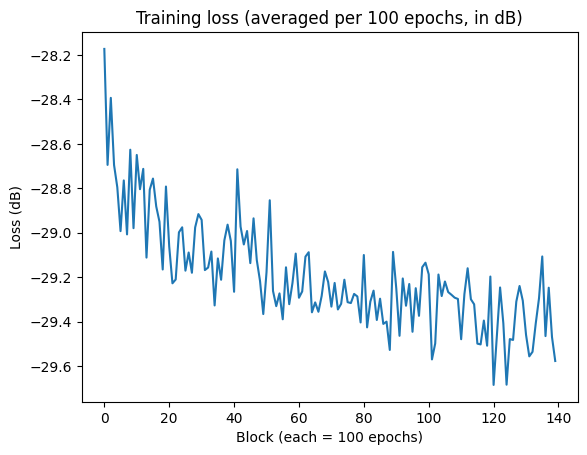

In [22]:

epoch_losses = np.array(epoch_losses)

N = 500  # group size
trim = len(epoch_losses) // N * N
loss_avg = epoch_losses[:trim].reshape(-1, N).mean(axis=1)

eps = 1e-12
loss_db = 10 * np.log10(loss_avg + eps)

plt.plot(loss_db)
plt.xlabel("Block (each = 100 epochs)")
plt.ylabel("Loss (dB)")
plt.title("Training loss (averaged per 100 epochs, in dB)")
plt.show()

Using test image: ./T91_test/t20.png
Scale 2: MSE on Y = 0.000897
Scale 3: MSE on Y = 0.002396


/tmp/ipython-input-1406130981.py:39: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pred_y_img = Image.fromarray(pred_y_255, mode="L")


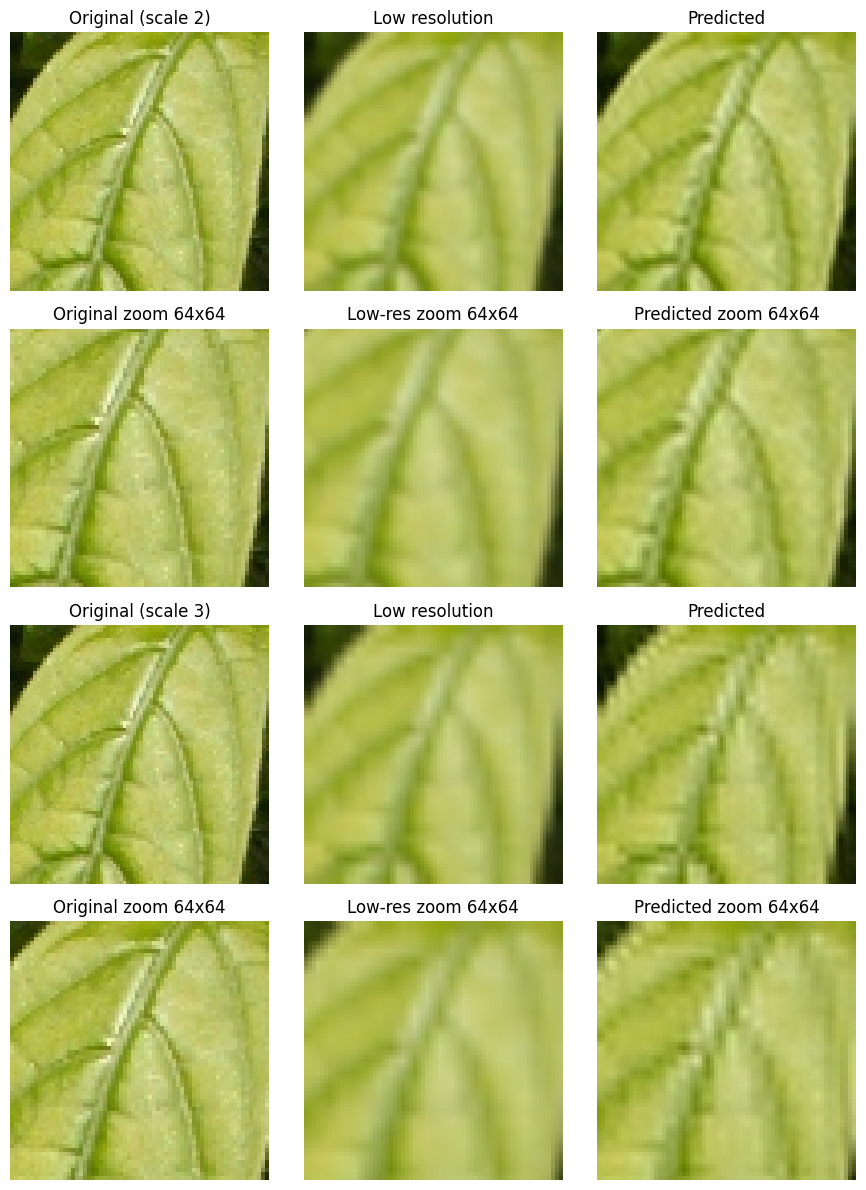

In [17]:

test_images = glob.glob("./T91_test/*.png")
if not test_images:
    raise RuntimeError("No images found in ./T91_test")

img_path = random.choice(test_images)
print("Using test image:", img_path)

hr_img_rgb = Image.open(img_path).convert("RGB")

model.eval()

scales = [2, 3]

fig, axes = plt.subplots(len(scales) * 2, 3, figsize=(9, 6 * len(scales)))

if len(scales) * 2 == 2:
    axes = np.array(axes).reshape(2, 3)

for i, scale in enumerate(scales):
    lr_img_rgb = make_low_resolution(hr_img_rgb, scale)

    hr_y = rgb_to_y(hr_img_rgb) / 255.0
    lr_y = rgb_to_y(lr_img_rgb) / 255.0

    lr_tensor = torch.from_numpy(lr_y).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_tensor = model(lr_tensor).clamp(0.0, 1.0)

    pred_y = pred_tensor.squeeze().cpu().numpy()

    mse = np.mean((hr_y - pred_y) ** 2)
    print(f"Scale {scale}: MSE on Y = {mse:.6f}")

    ycbcr_lr = lr_img_rgb.convert("YCbCr")
    _, cb_lr, cr_lr = ycbcr_lr.split()

    pred_y_255 = (pred_y * 255.0).clip(0, 255).astype(np.uint8)
    pred_y_img = Image.fromarray(pred_y_255, mode="L")
    pred_ycbcr_img = Image.merge("YCbCr", (pred_y_img, cb_lr, cr_lr))
    pred_rgb_img = pred_ycbcr_img.convert("RGB")

    row_full = 2 * i
    row_zoom = 2 * i + 1

    axes[row_full, 0].imshow(hr_img_rgb)
    axes[row_full, 0].set_title(f"Original (scale {scale})")
    axes[row_full, 0].axis("off")

    axes[row_full, 1].imshow(lr_img_rgb)
    axes[row_full, 1].set_title("Low resolution")
    axes[row_full, 1].axis("off")

    axes[row_full, 2].imshow(pred_rgb_img)
    axes[row_full, 2].set_title("Predicted")
    axes[row_full, 2].axis("off")

    w, h = hr_img_rgb.size
    crop_w, crop_h = 64, 64
    if w < crop_w or h < crop_h:
        x0, y0 = 0, 0
    else:
        x0 = random.randint(0, w - crop_w)
        y0 = random.randint(0, h - crop_h)
    box = (x0, y0, x0 + crop_w, y0 + crop_h)

    hr_crop = hr_img_rgb.crop(box)
    lr_crop = lr_img_rgb.crop(box)
    pred_crop = pred_rgb_img.crop(box)

    axes[row_zoom, 0].imshow(hr_crop)
    axes[row_zoom, 0].set_title("Original zoom 64x64")
    axes[row_zoom, 0].axis("off")

    axes[row_zoom, 1].imshow(lr_crop)
    axes[row_zoom, 1].set_title("Low-res zoom 64x64")
    axes[row_zoom, 1].axis("off")

    axes[row_zoom, 2].imshow(pred_crop)
    axes[row_zoom, 2].set_title("Predicted zoom 64x64")
    axes[row_zoom, 2].axis("off")

plt.tight_layout()
plt.show()

In [5]:
state = torch.load("super_resolution_model.pth", map_location=device)
model.load_state_dict(state)
model.eval()


SuperResolutionSRCNN(
  (conv1): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (relu1): ReLU(inplace=True)
  (conv2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU(inplace=True)
  (conv3): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)

In [10]:
def evaluate_dataset_on_scale(dataset_name: str, scale: int):
    ds = load_dataset(dataset_name, split="train")

    psnr_lr_list = []
    ssim_lr_list = []
    psnr_pred_list = []
    ssim_pred_list = []

    for sample in ds:
        img = sample["image"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)

        hr_img_rgb = img.convert("RGB")
        lr_img_rgb = make_low_resolution(hr_img_rgb, scale)

        hr_y = rgb_to_y(hr_img_rgb) / 255.0
        lr_y = rgb_to_y(lr_img_rgb) / 255.0

        lr_tensor = torch.from_numpy(lr_y).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            pred_tensor = model(lr_tensor).clamp(0.0, 1.0)

        pred_y = pred_tensor.squeeze().cpu().numpy()

        psnr_lr = peak_signal_noise_ratio(hr_y, lr_y, data_range=1.0)
        ssim_lr = structural_similarity(hr_y, lr_y, data_range=1.0)
        psnr_pred = peak_signal_noise_ratio(hr_y, pred_y, data_range=1.0)
        ssim_pred = structural_similarity(hr_y, pred_y, data_range=1.0)

        psnr_lr_list.append(psnr_lr)
        ssim_lr_list.append(ssim_lr)
        psnr_pred_list.append(psnr_pred)
        ssim_pred_list.append(ssim_pred)

    print(f"\nDataset: {dataset_name}, scale = {scale}")
    print("  Original vs LowRes:")
    print("    PSNR [dB] mean = {:.2f}, std = {:.2f}".format(
        np.mean(psnr_lr_list), np.std(psnr_lr_list)))
    print("    SSIM [-] mean = {:.4f}, std = {:.4f}".format(
        np.mean(ssim_lr_list), np.std(ssim_lr_list)))

    print("  Original vs Predicted:")
    print("    PSNR [dB] mean = {:.2f}, std = {:.2f}".format(
        np.mean(psnr_pred_list), np.std(psnr_pred_list)))
    print("    SSIM [-] mean = {:.4f}, std = {:.4f}".format(
        np.mean(ssim_pred_list), np.std(ssim_pred_list)))


In [13]:
print('Evaluate Set5 with scale 2')
evaluate_dataset_on_scale("Voxel51/Set5", scale=2)
print('Evaluate Set14 with scale 2')
evaluate_dataset_on_scale("Voxel51/Set14", scale=2)
print('Evaluate Set5 with scale 3')
evaluate_dataset_on_scale("Voxel51/Set5", scale=3)
print('Evaluate Set14 with scale 3')
evaluate_dataset_on_scale("Voxel51/Set14", scale=3)

Evaluate Set5 with scale 2

Dataset: Voxel51/Set5, scale = 2
  Original vs LowRes:
    PSNR [dB] mean = 32.25, std = 5.40
    SSIM [-] mean = 0.9299, std = 0.0564
  Original vs Predicted:
    PSNR [dB] mean = 38.10, std = 6.06
    SSIM [-] mean = 0.9680, std = 0.0308
Evaluate Set14 with scale 2

Dataset: Voxel51/Set14, scale = 2
  Original vs LowRes:
    PSNR [dB] mean = 31.07, std = 4.69
    SSIM [-] mean = 0.9064, std = 0.0773
  Original vs Predicted:
    PSNR [dB] mean = 37.03, std = 6.06
    SSIM [-] mean = 0.9585, std = 0.0466
Evaluate Set5 with scale 3

Dataset: Voxel51/Set5, scale = 3
  Original vs LowRes:
    PSNR [dB] mean = 29.25, std = 5.09
    SSIM [-] mean = 0.8744, std = 0.0862
  Original vs Predicted:
    PSNR [dB] mean = 30.72, std = 5.26
    SSIM [-] mean = 0.8990, std = 0.0698
Evaluate Set14 with scale 3

Dataset: Voxel51/Set14, scale = 3
  Original vs LowRes:
    PSNR [dB] mean = 28.29, std = 4.21
    SSIM [-] mean = 0.8414, std = 0.1091
  Original vs Predicted:
    